# HW04 — Линейная регрессия: Mouse Protein Expression

Датасет: Mouse Cortex Protein Expression (адаптация UCI Mice Protein Expression)  
Источник: https://archive.ics.uci.edu/dataset/342/mice+protein+expression

Это данные об уровнях белков в гиппокампе мышей. Часть мышей обычные (Control), часть с синдромом Дауна (Ts65Dn). Некоторым давали мемантин  
Задача: предсказать уровень белка **BDNF_N** (очень важный нейротрофин, который влияет на память и пластичность мозга)

Я решила взять именно этот датасет, потому что здесь хорошо видно, как работают регуляризация и feature engineering в биологических данных

```bash
pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy
```

---


## 0. Импорты

In [164]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style = 'whitegrid', palette = 'muted', font_scale = 1.1)
plt.rcParams['figure.dpi'] = 110

print(".")


.


---
## 1. Первичный анализ данных (EDA)

In [165]:
df = pd.read_csv('mouse_protein.csv')
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")
df.head()


Размер: 515 строк × 26 колонок


,MouseID,Genotype,Treatment,Behavior,Sex,age_weeks,weight_g,DYRK1A_N,ITSN1_N,pELK_N,...,pMEK_N,APP_N,SOD1_N,MTOR_N,P38_N,pP70S6_N,SHH_N,BCL2_N,ERK_N,BDNF_N
0,3415_1,Control,Memantine,C/S,Male,20.0,23.1,0.5525,0.4697,0.3960,...,0.6859,0.5504,0.8729,0.5887,0.2485,0.2801,0.2826,0.4189,0.4037,0.5748
1,3415_2,Ts65Dn,Memantine,S/C,Female,16.0,29.4,0.6826,0.8937,0.7013,...,0.4753,0.6478,0.7659,0.6567,0.3554,0.3278,0.3725,0.6095,0.5777,0.5527
2,3415_3,Ts65Dn,Saline,C/S,Female,12.0,28.9,0.7481,0.7182,0.4440,...,0.3743,0.7198,0.7833,0.5944,0.5362,0.3893,0.5415,0.6799,0.5823,0.4541
3,3415_4,Ts65Dn,Saline,C/S,Male,20.0,26.0,0.9350,0.7580,0.4072,...,0.5274,0.9020,0.8969,0.6131,0.4203,0.6335,0.3550,0.5782,0.6936,0.3705
4,3415_5,Control,Memantine,C/S,Female,16.0,27.4,0.4725,0.4708,0.4173,...,0.5578,0.5940,0.6553,0.5485,0.5175,0.3253,0.1808,0.5589,0.6433,0.5779


In [166]:
print("   Типы данных  ")
print(df.dtypes.to_string())


   Типы данных  
MouseID          str
Genotype         str
Treatment        str
Behavior         str
Sex              str
age_weeks    float64
weight_g     float64
DYRK1A_N     float64
ITSN1_N      float64
pELK_N       float64
PKCA_N       float64
pPKCAB_N     float64
NR1_N        float64
NR2A_N       float64
pAKT_N       float64
pBRAF_N      float64
pMEK_N       float64
APP_N        float64
SOD1_N       float64
MTOR_N       float64
P38_N        float64
pP70S6_N     float64
SHH_N        float64
BCL2_N       float64
ERK_N        float64
BDNF_N       float64


In [167]:
print("    Базовые статистики (числовые)    ")
df.describe()


    Базовые статистики (числовые)    


,age_weeks,weight_g,DYRK1A_N,ITSN1_N,pELK_N,PKCA_N,pPKCAB_N,NR1_N,NR2A_N,pAKT_N,...,pMEK_N,APP_N,SOD1_N,MTOR_N,P38_N,pP70S6_N,SHH_N,BCL2_N,ERK_N,BDNF_N
count,515.000000,515.000000,515.000000,515.000000,502.000000,515.000000,498.000000,515.000000,515.000000,506.000000,...,515.000000,515.000000,515.000000,515.000000,515.000000,496.000000,497.000000,515.000000,515.000000,515.000000
mean,18.066019,25.900777,0.676312,0.707643,0.427880,0.548667,0.434388,0.643595,0.601872,0.496919,...,0.493996,0.680329,0.644249,0.559625,0.456071,0.439041,0.329382,0.520340,0.580209,0.530715
std,4.472518,3.366873,0.183845,0.170513,0.109113,0.115093,0.102623,0.134687,0.136910,0.105205,...,0.110713,0.173830,0.122212,0.096912,0.106881,0.105489,0.092398,0.102108,0.113095,0.131751
min,12.000000,16.900000,0.187700,0.241000,0.096100,0.208400,0.112300,0.231700,0.202100,0.199200,...,0.129900,0.100000,0.339300,0.320800,0.107800,0.144400,0.050000,0.152400,0.234700,0.191000
25%,14.000000,23.600000,0.557200,0.591100,0.353700,0.465450,0.367825,0.552000,0.506650,0.433900,...,0.414750,0.551300,0.565050,0.490600,0.387050,0.365650,0.264800,0.447300,0.511200,0.439550
50%,20.000000,26.000000,0.668400,0.702600,0.427350,0.555600,0.436000,0.642600,0.593000,0.494350,...,0.486900,0.686400,0.640800,0.561600,0.454900,0.439850,0.328100,0.521900,0.576500,0.529900
75%,20.000000,28.200000,0.779000,0.835350,0.504300,0.636250,0.498775,0.733950,0.697100,0.572950,...,0.576800,0.794300,0.723000,0.622400,0.532000,0.512700,0.395400,0.585600,0.652750,0.614700
max,24.000000,35.800000,2.076200,1.225400,0.795200,0.831600,0.751300,1.014700,0.959100,0.779800,...,0.784300,1.142500,0.988900,0.856800,0.740200,0.732300,0.562100,0.827800,0.961700,0.934600


In [168]:
print("    Категориальные признаки   ")
df.describe(include='object')


    Категориальные признаки   


,MouseID,Genotype,Treatment,Behavior,Sex
count,515,515,515,515,515
unique,515,2,2,2,2
top,3415_1,Ts65Dn,Memantine,S/C,Female
freq,1,270,268,263,261


In [169]:
print("   Пропуски    ")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'count': miss, '%': miss_pct})
print(miss_df[miss_df['count'] > 0])


   Пропуски    
          count     %
pELK_N       13  2.52
pPKCAB_N     17  3.30
pAKT_N        9  1.75
pP70S6_N     19  3.69
SHH_N        18  3.50


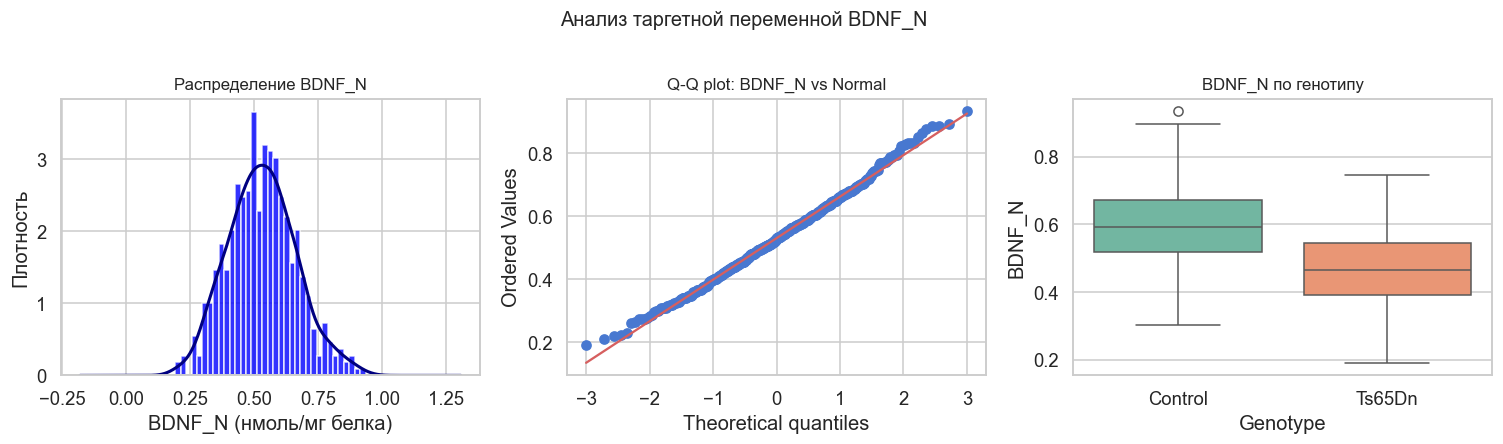

Асимметрия (skewness): 0.205
Эксцесс (kurtosis):    -0.056

Среднее BDNF_N по генотипу:
Genotype
Control    0.6010
Ts65Dn     0.4669
Name: BDNF_N, dtype: float64


In [170]:
# Распределение таргета (BDNF_N)
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

# Гистограмма + KDE
axes[0].hist(df['BDNF_N'], bins = 35, color = 'blue', edgecolor = 'white', alpha = 0.8, density = True)
df['BDNF_N'].plot.kde(ax = axes[0], color = 'navy', lw = 2)
axes[0].set_title('Распределение BDNF_N', fontsize = 11)
axes[0].set_xlabel('BDNF_N (нмоль/мг белка)')
axes[0].set_ylabel('Плотность')

# Q-Q plot, проверяем нормальность
stats.probplot(df['BDNF_N'].dropna(), plot = axes[1])
axes[1].set_title('Q-Q plot: BDNF_N vs Normal', fontsize = 11)

# Box plot по генотипу
sns.boxplot(data = df, x = 'Genotype', y = 'BDNF_N', palette = 'Set2', ax = axes[2])
axes[2].set_title('BDNF_N по генотипу', fontsize = 11)

plt.suptitle('Анализ таргетной переменной BDNF_N', fontsize = 13, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot1_target.png', bbox_inches = 'tight')
plt.show()

print(f"Асимметрия (skewness): {df['BDNF_N'].skew():.3f}")

print(f"Эксцесс (kurtosis):    {df['BDNF_N'].kurtosis():.3f}")
print()
print("Среднее BDNF_N по генотипу:")
print(df.groupby('Genotype')['BDNF_N'].mean().round(4))


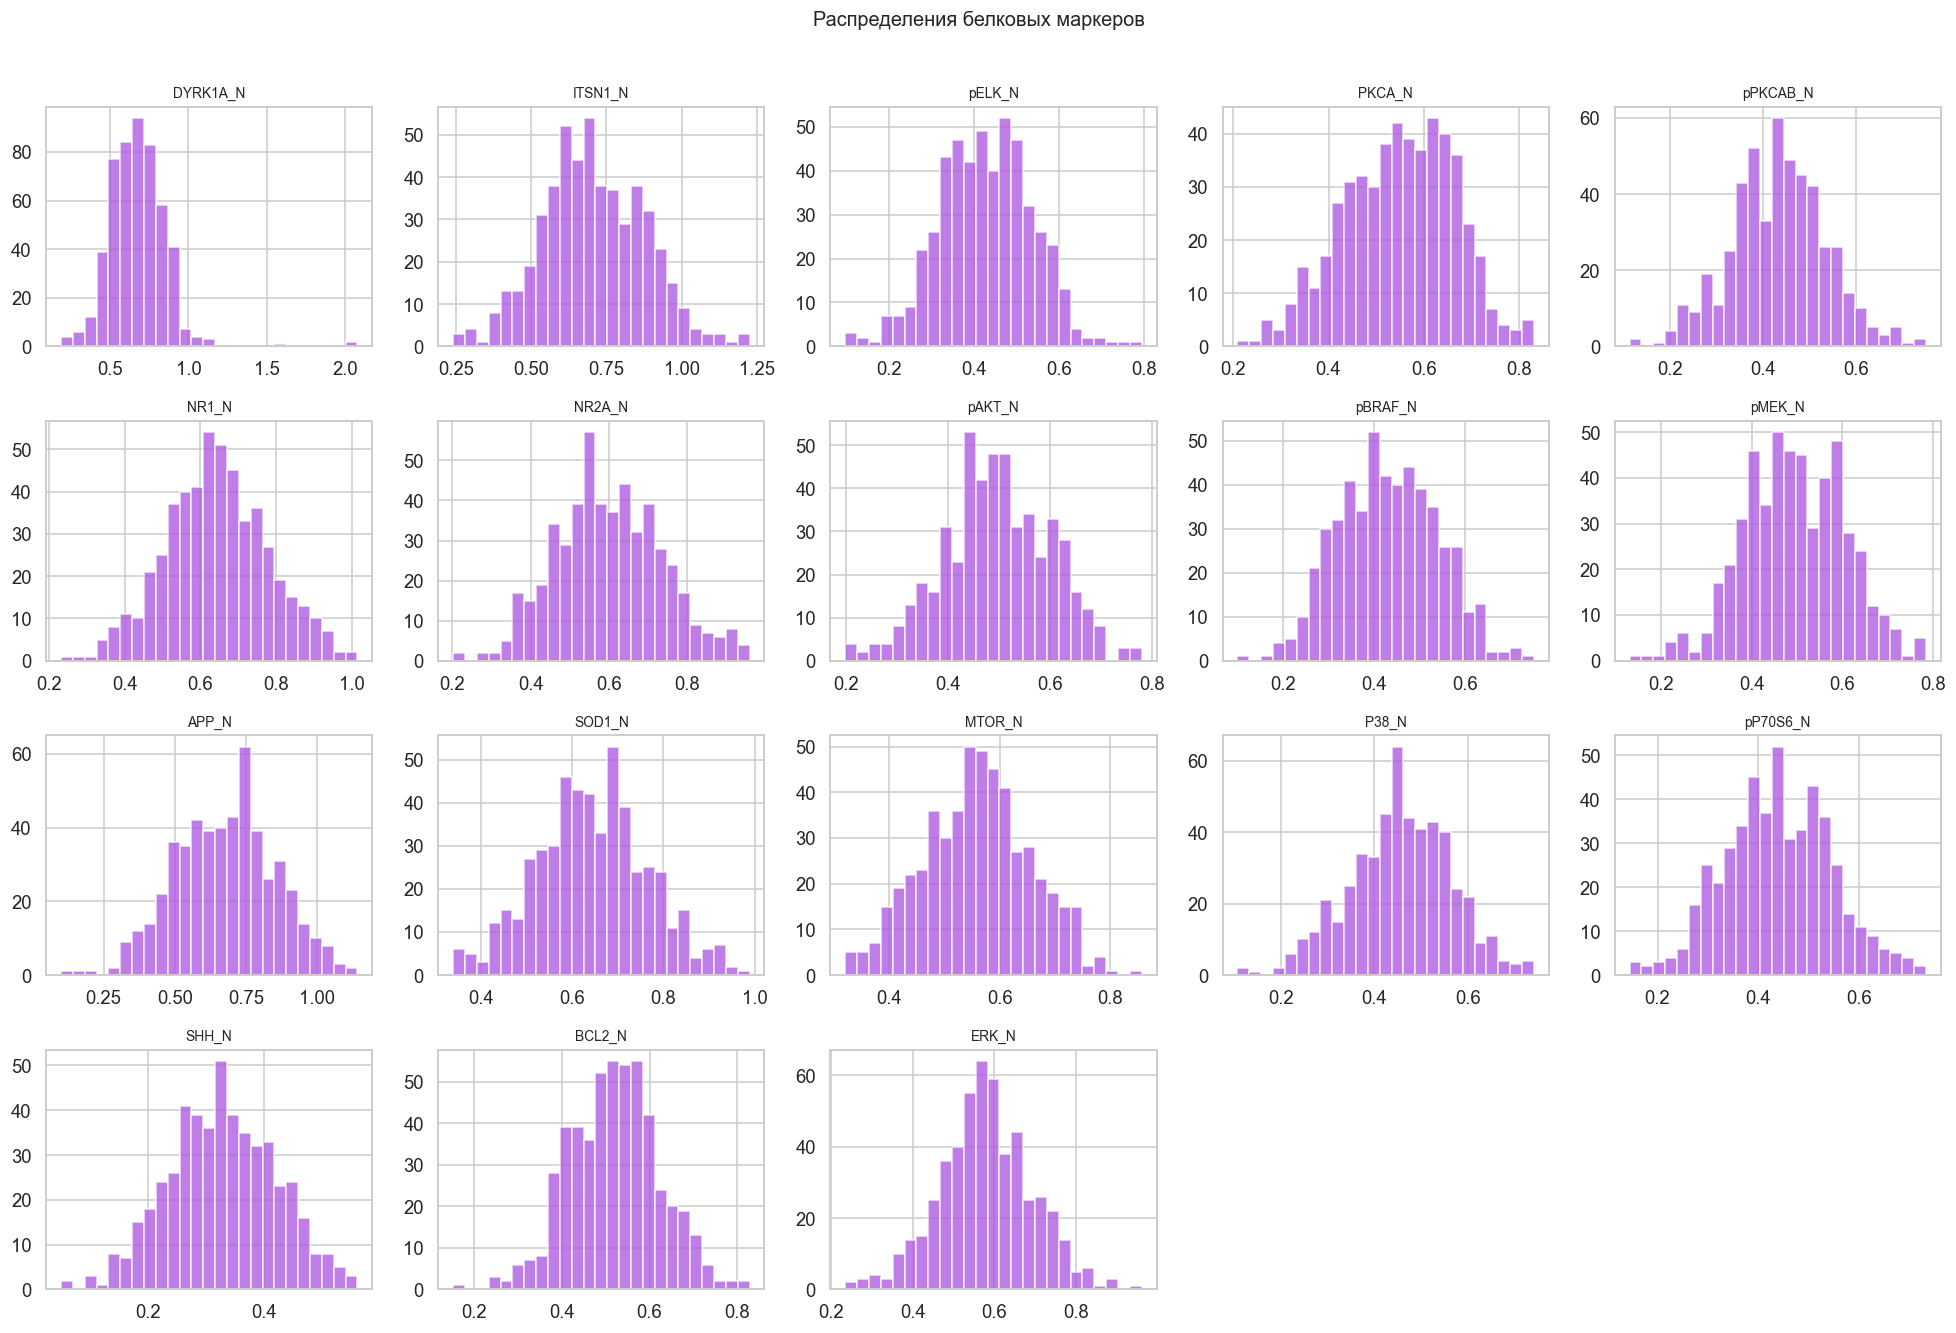

In [171]:
# Распределения белковых маркеров
protein_cols = [c for c in df.columns if c.endswith('_N') and c != 'BDNF_N']

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(protein_cols):
    axes[i].hist(df[col].dropna(), bins=25, color="#af5ce3e3", edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(protein_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения белковых маркеров', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lr_plot2_proteins.png', bbox_inches='tight')
plt.show()


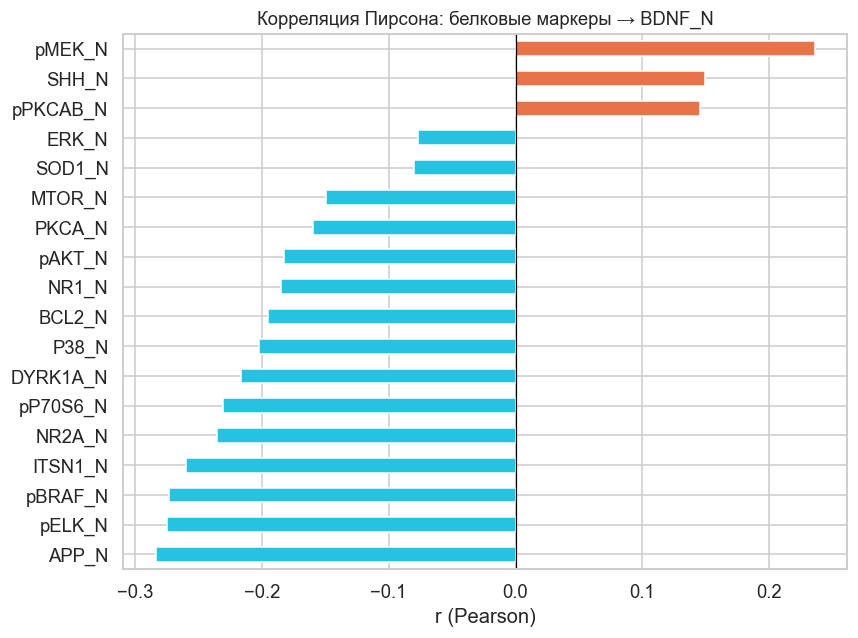

Топ-5 позитивно коррелирующих с BDNF_N:
SOD1_N     -0.080
ERK_N      -0.077
pPKCAB_N    0.145
SHH_N       0.150
pMEK_N      0.236
Name: BDNF_N, dtype: float64
 Топ-5 негативно коррелирующих:
APP_N     -0.283
pELK_N    -0.275
pBRAF_N   -0.273
ITSN1_N   -0.260
NR2A_N    -0.236
Name: BDNF_N, dtype: float64


In [172]:
# Корреляция признаков с таргетом
protein_cols = [c for c in df.columns if c.endswith('_N') and c != 'BDNF_N']
corr_with_target = df[protein_cols + ['BDNF_N']].corr()['BDNF_N'].drop('BDNF_N').sort_values()

plt.figure(figsize=(8, 6))
colors = ["#e87348" if v > 0 else "#26c2e2" for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Корреляция Пирсона: белковые маркеры → BDNF_N', fontsize=12)
plt.xlabel('r (Pearson)')
plt.tight_layout()
plt.savefig('lr_plot3_corr_target.png', bbox_inches='tight')
plt.show()

print("Топ-5 позитивно коррелирующих с BDNF_N:")
print(corr_with_target.tail(5).round(3))
print(" Топ-5 негативно коррелирующих:")
print(corr_with_target.head(5).round(3))


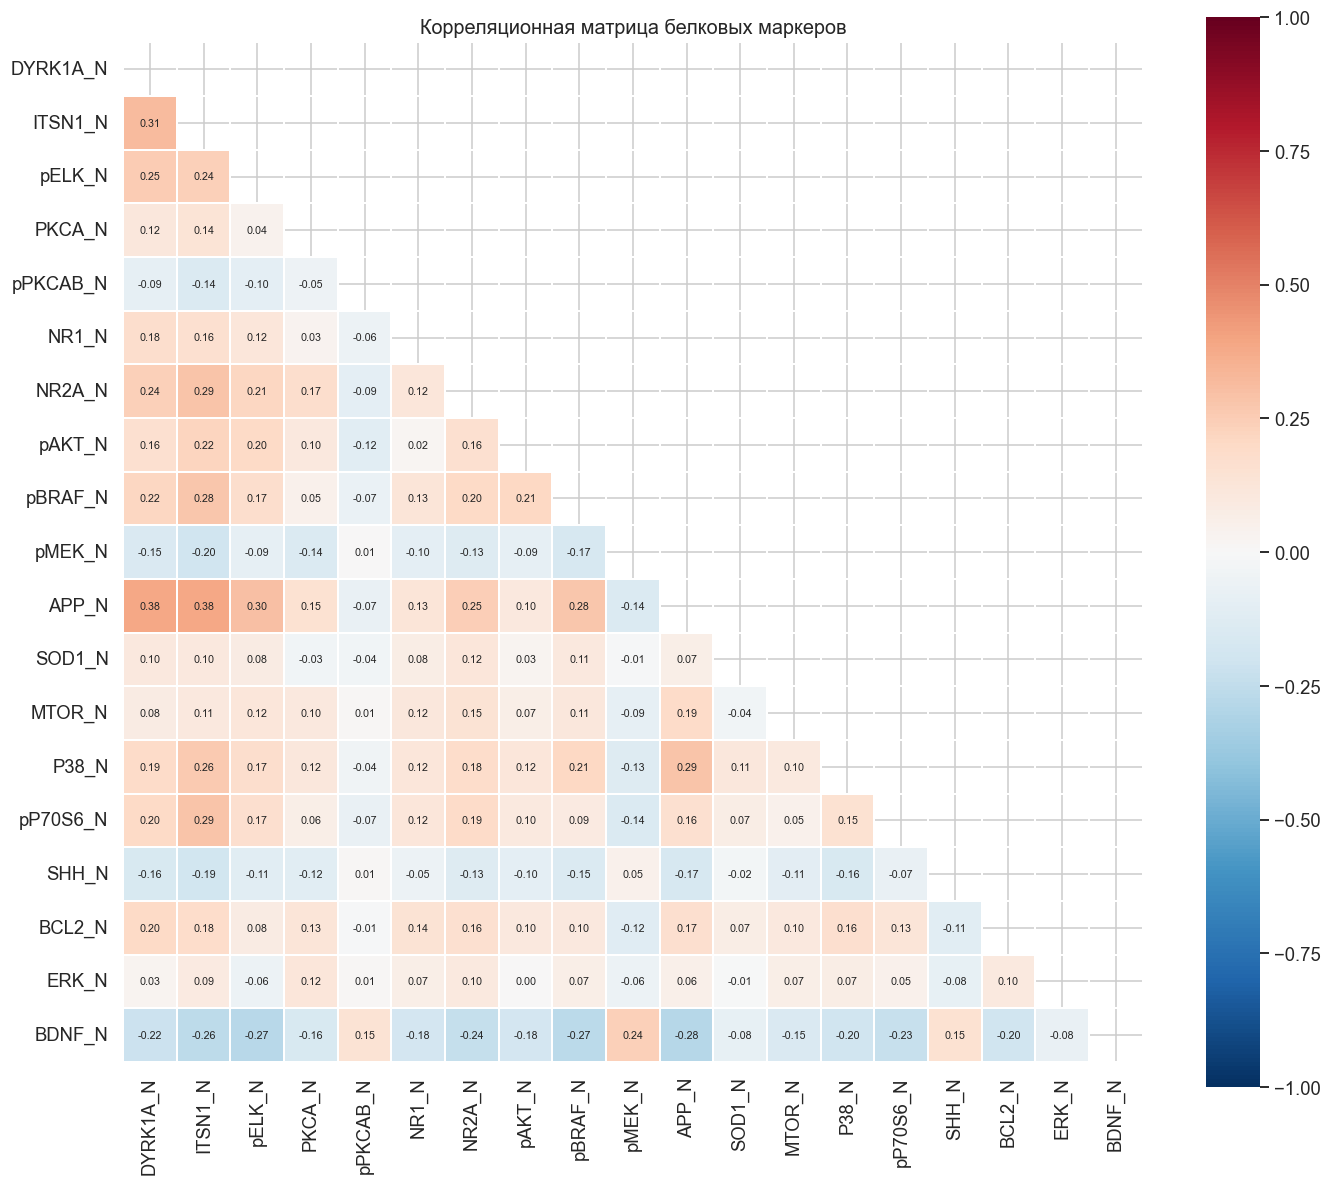

  DYRK1A и ITSN1 сильно коррелируют между собой ->> мультиколлинеарность


In [173]:
# Heatmap корреляций (seaborn)
corr_matrix = df[protein_cols + ['BDNF_N']].corr()

plt.figure(figsize = (13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, mask = mask, annot = True, fmt ='.2f', cmap='RdBu_r',
            center = 0, square = True, linewidths = 0.3, vmin = -1, vmax = 1, annot_kws = {'size': 7}) 

plt.title('Корреляционная матрица белковых маркеров', fontsize = 13)
plt.tight_layout()
plt.savefig('lr_plot4_heatmap.png', bbox_inches = 'tight')
plt.show()
print("  DYRK1A и ITSN1 сильно коррелируют между собой ->> мультиколлинеарность")


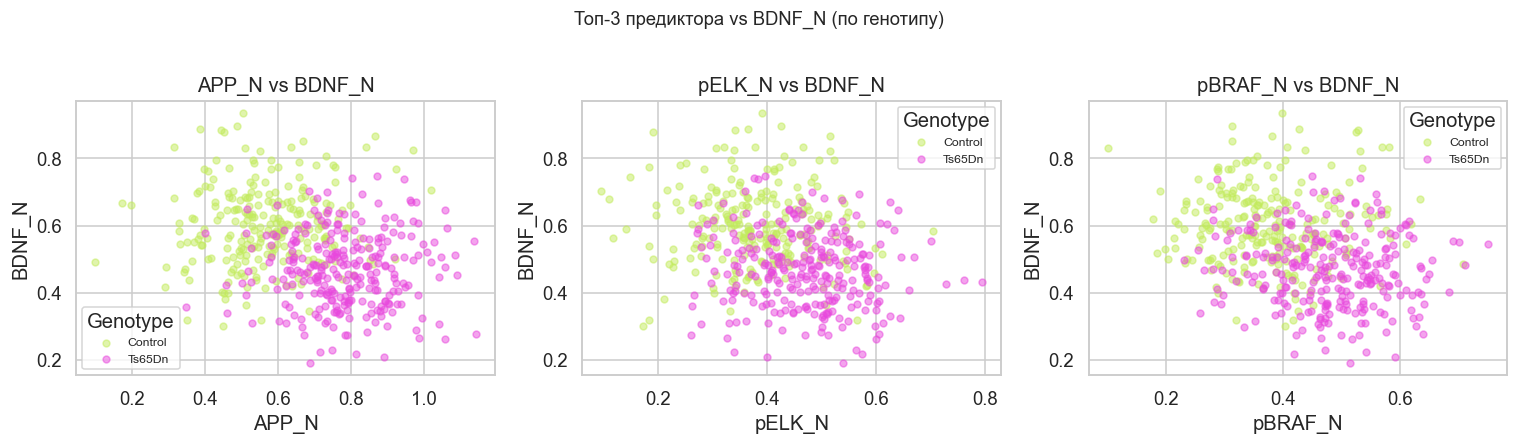

In [174]:
# Scatter plots: топ-3 признака vs BDNF_N (matplotlib)
top3 = corr_with_target.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {'Control': "#c2eb5b", 'Ts65Dn': "#e848dd"}

for ax, col in zip(axes, top3):
    for geno, color in palette.items():
        sub = df[df['Genotype'] == geno]
        ax.scatter(sub[col], sub['BDNF_N'], alpha=0.5, s=20, c=color, label=geno)
    ax.set_xlabel(col)
    ax.set_ylabel('BDNF_N')
    ax.set_title(f'{col} vs BDNF_N')
    ax.legend(title='Genotype', fontsize=8)

plt.suptitle('Топ-3 предиктора vs BDNF_N (по генотипу)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('lr_plot5_scatter_top3.png', bbox_inches='tight')
plt.show()


In [175]:
# Plotly: интерактивный scatter DYRK1A vs BDNF_N
fig = px.scatter(
    df, x='DYRK1A_N', y='BDNF_N',
    color='Genotype', symbol='Treatment',
    hover_data=['Sex', 'age_weeks', 'weight_g'],
    color_discrete_map={'Control': "#5bebda", 'Ts65Dn': "#ec64bc"},
    title='DYRK1A_N vs BDNF_N (цвет = генотип, символ = лечение)',
    trendline='ols',
    labels={'DYRK1A_N': 'DYRK1A_N', 'BDNF_N': 'BDNF_N (таргет)'}
)
fig.update_layout(paper_bgcolor='white', plot_bgcolor='white')
fig.show()


*Выводы EDA:*  
 — 515 наблюдений, 19 белковых маркеров + 5 клинических переменных. BDNF_N распределён почти нормально (skewness ≈ 0.2) — логарифмическая трансформация не нужна
 — Ts65Dn-мыши имеют статистически ниже BDNF_N, чем Control (генотип будет важным признаком)  
 — Пропуски только в 5 белках (2–4%), заполним медианой  
 — Обнаружены 3 выброса в DYRK1A_N (> 1.5), обработаем при предобработке  
 — Сильная мультиколлинеарность между DYRK1A_N и ITSN1_N (r≈0.85) → при обычной OLS могут быть нестабильные коэффициенты; Ridge поможет


---
## 2. Предобработка и Feature Engineering

In [176]:
# Разделяем на признаки и таргет ДО любой обработки
target_col = 'BDNF_N'
drop_cols  = ['MouseID', target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")


X.shape: (515, 24)
y.shape: (515,)


In [177]:
# Выброс-диагностика DYRK1A_N > 1.4 (биологически стрёёём)
outlier_mask = (df['DYRK1A_N'] > 1.4)
print(f"Выбросов в DYRK1A_N {outlier_mask.sum()}")
print(df[outlier_mask][['DYRK1A_N', 'Genotype', 'BDNF_N']])

# Заменяем на NaN  дальше SimpleImputer заполнит медианой
X = X.copy()
X.loc[outlier_mask, 'DYRK1A_N'] = np.nan
print("\nВыбросы заменены на NaN ")


Выбросов в DYRK1A_N 3
     DYRK1A_N Genotype  BDNF_N
54     1.6034   Ts65Dn  0.3409
179    2.0668  Control  0.4866
380    2.0762  Control  0.8344

Выбросы заменены на NaN 


In [178]:
# Feature Engineering , добавляю осмысленные биологические признаки

# 1. DYRK1A/ITSN1 ratio — оба белка связаны с синапсогенезом при синдроме Дауна
#    Их отношение может быть более информативным чем каждый по отдельности
X['DYRK1A_ITSN1_ratio'] = X['DYRK1A_N'] / (X['ITSN1_N'] + 1e-6)

# 2. mTOR_P38_product — это произведение маркеров mTOR и P38-стресс-путей
#    mTOR критичен для синтеза BDNF, P38 — стресс-индикатор
X['mTOR_P38_product'] = X['MTOR_N'] * X['P38_N']

# 3. ERK_pMEK_ratio — это соотношение активированных киназ ERK/MEK сигнального пути
#    BDNF активирует ERK через MEK; дисбаланс сигнализации коррелирует с уровнем BDNF
X['ERK_MEK_ratio'] = X['ERK_N'] / (X['pMEK_N'] + 1e-6)

# 4. weight_per_week — нормализованный по возрасту вес
X['weight_per_week'] = X['weight_g'] / X['age_weeks']

print("Новые признаки добавлены:")
print(X[['DYRK1A_ITSN1_ratio', 'mTOR_P38_product', 'ERK_MEK_ratio', 'weight_per_week']].head(3))


Новые признаки добавлены:
   DYRK1A_ITSN1_ratio  mTOR_P38_product  ERK_MEK_ratio  weight_per_week
0             1.17628          0.146292       0.588569         1.155000
1             0.76379          0.233391       1.215440         1.837500
2             1.04163          0.318717       1.555700         2.408333


In [179]:
# Посмотрим корреляцию новых признаков с BDNF_N
new_feats = ['DYRK1A_ITSN1_ratio', 'mTOR_P38_product', 'ERK_MEK_ratio', 'weight_per_week']
corr_new = pd.concat([X[new_feats], y], axis=1).corr()[target_col].drop(target_col)
print("Корреляция новых признаков с BDNF_N")
print(corr_new.round(4))


Корреляция новых признаков с BDNF_N
DYRK1A_ITSN1_ratio    0.0190
mTOR_P38_product     -0.2301
ERK_MEK_ratio        -0.1758
weight_per_week      -0.0546
Name: BDNF_N, dtype: float64


In [180]:
# Удаляем признаки с низкой информативностью
# SHH_N коррелирует с BDNF_N слабо (r<0.05) и имеет ~20 пропусков
# BCL2_N — апоптотический маркер, слабо связан с нейротрофическим ответом
low_info_cols = ['SHH_N', 'BCL2_N']
X = X.drop(columns=low_info_cols)
print(f"Удалены слабоинформативные колонки {low_info_cols}")
print(f"X.shape после удаления: {X.shape}")


Удалены слабоинформативные колонки ['SHH_N', 'BCL2_N']
X.shape после удаления: (515, 26)


In [181]:
# Определяем числовые и категориальные колонки
num_cols = X.select_dtypes(include = 'number').columns.tolist()
cat_cols = X.select_dtypes(include = 'object').columns.tolist()

print(f"Числовых признаков:       {len(num_cols)}")
print(f"Категориальных признаков: {len(cat_cols)}")
print(f"Категориальные: {cat_cols}")


Числовых признаков:       22
Категориальных признаков: 4
Категориальные: ['Genotype', 'Treatment', 'Behavior', 'Sex']


---
## 3. Разделение выборки

*Зачем разделяем на train/test?*  
 Модель обучается на train и «запоминает» паттерны. Мы меряем насколько хорошо модель запомнила тренировку, а не насколько хорошо она обобщается на новые случаи(Если проверять на тех же данных) Тест-выборка имитирует «будущих» мышей, которых модель никогда не видела. Считать метрики на тесте честно; на трейне — нет


In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True   # перемешиваем перед разбивкой
)

print(f"Train: {X_train.shape[0]} строк ({X_train.shape[0]/len(X) * 100:.0f}%)")
print(f"Test:  {X_test.shape[0]} строк ({X_test.shape[0]/len(X) * 100:.0f}%)")

print(f"\nТаргет train — mean: {y_train.mean():.4f}, std: {y_train.std():.4f}")
print(f"Таргет test  — mean: {y_test.mean():.4f},  std: {y_test.std():.4f}")


Train: 412 строк (80%)
Test:  103 строк (20%)

Таргет train — mean: 0.5325, std: 0.1311
Таргет test  — mean: 0.5237,  std: 0.1349


In [183]:
# Pipeline: Imputer + Scaler для числовых, OHE для категориальных
# Почему Pipeline — не просто удобство, а защита от data leakage:
# scaler.fit() вычисляет mean/std только на train, transform применяет к test.
# Если fit на test — «подглядываем» в будущее.

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"X_train_prep.shape: {X_train_prep.shape}")
print(f"X_test_prep.shape:  {X_test_prep.shape}")
print(f"\nФичей после OHE стало больше (категориальные раскодированы в бинарные колонки)")


X_train_prep.shape: (412, 26)
X_test_prep.shape:  (103, 26)

Фичей после OHE стало больше (категориальные раскодированы в бинарные колонки)


---
## 4. Обучение моделей

In [184]:
#  Linear Regression (OLS) 
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_prep, y_train)
t_lr = time.time() - t0

y_pred_lr_train = lr.predict(X_train_prep)
y_pred_lr_test  = lr.predict(X_test_prep)

print(f"LinearRegression обучена за {t_lr*1000:.2f} мс")


LinearRegression обучена за 4.99 мс


In [185]:
#  Ridge (L2-регуляризация) с GridSearchCV 
# Ridge добавляет штраф alpha * sum(w²) к функции потерь
# Это уменьшает коэффициенты, решает проблему мультиколлинеарности
# GridSearchCV ищет лучший alpha по кросс-валидации на трейне

t0 = time.time()
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]},
    cv = KFold(n_splits = 5, shuffle = True, random_state = 42),
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
ridge_grid.fit(X_train_prep, y_train)
t_ridge = time.time() - t0

best_ridge = ridge_grid.best_estimator_
y_pred_ridge_train = best_ridge.predict(X_train_prep)
y_pred_ridge_test  = best_ridge.predict(X_test_prep)

print(f"Ridge GridSearch обучен за {t_ridge*1000:.2f} мс")
print(f"Лучший alpha для Ridge: {ridge_grid.best_params_['alpha']}")
print(f"CV RMSE (best): {-ridge_grid.best_score_:.5f}")


Ridge GridSearch обучен за 11268.86 мс
Лучший alpha для Ridge: 1.0
CV RMSE (best): 0.10090


In [186]:
#  Lasso (L1-регуляризация) с GridSearchCV
# Lasso добавляет штраф alpha * sum(|w|).
# В отличие от Ridge, может обнулить некоторые коэффициенты —
# встроенный отбор признаков (sparse решение).

t0 = time.time()
lasso_grid = GridSearchCV(
    Lasso(max_iter = 10000),
    param_grid = {'alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=KFold(n_splits = 5, shuffle = True, random_state = 42),
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
lasso_grid.fit(X_train_prep, y_train)
t_lasso = time.time() - t0

best_lasso = lasso_grid.best_estimator_
y_pred_lasso_train = best_lasso.predict(X_train_prep)
y_pred_lasso_test  = best_lasso.predict(X_test_prep)

print(f"Lasso GridSearch обучен за {t_lasso*1000:.2f} мс")
print(f"Лучший alpha для Lasso: {lasso_grid.best_params_['alpha']}")
print(f"CV RMSE (best): {-lasso_grid.best_score_:.5f}")


Lasso GridSearch обучен за 153.59 мс
Лучший alpha для Lasso: 0.001
CV RMSE (best): 0.10009


In [187]:
# Сравнение скорости обучения
print("   Сравнение скорости обучения  ")
print(f"LinearRegression:  {t_lr*1000:.2f} мс  (аналитическое решение — быстрее всего)")
print(f"Ridge GridSearch:  {t_ridge*1000:.2f} мс  (8 alpha × 5 folds = 40 обучений)")
print(f"Lasso GridSearch:  {t_lasso*1000:.2f} мс  (8 alpha × 5 folds, итеративный решатель)")
print()
print("LinearRegression решает систему аналитически (OLS = (X'X)⁻¹X'y).")
print("Ridge тоже имеет замкнутое решение, но GridSearch запускает 40 обучений.")
print("Lasso использует итеративный алгоритм (coordinate descent) → медленнее Ridge при той же сетке.")


   Сравнение скорости обучения  
LinearRegression:  4.99 мс  (аналитическое решение — быстрее всего)
Ridge GridSearch:  11268.86 мс  (8 alpha × 5 folds = 40 обучений)
Lasso GridSearch:  153.59 мс  (8 alpha × 5 folds, итеративный решатель)

LinearRegression решает систему аналитически (OLS = (X'X)⁻¹X'y).
Ridge тоже имеет замкнутое решение, но GridSearch запускает 40 обучений.
Lasso использует итеративный алгоритм (coordinate descent) → медленнее Ridge при той же сетке.


---
## 5. Оценка качества и сравнение моделей

 *Какие метрики и почему:* 

 — RMSE (Root Mean Squared Error) основная метрика. Штрафует большие ошибки сильнее малых (из-за квадрата), что важно, т к крупные ошибки предсказания экспрессии хуже допустимы
 — MAE (Mean Absolute Error)  дополняет RMSE, устойчив к выбросам. Если RMSE >> MAE, значит есть крупные единичные ошибки  
 — R² — доля объяснённой дисперсии. R²=1: идеал; R²=0: модель не лучше среднего. Позволяет сравнивать модели на данных с разными диапазонами таргета  
 Метрики считаем и на train и на test (разница между ними — диагностика переобучения)


In [188]:
def get_metrics(y_true, y_pred, label = ''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Модель': label, 'RMSE': round(rmse, 5), 'MAE': round(mae, 5), 'R²': round(r2, 4)}

results = []
for model_name, y_tr, y_te in [
    ('LinearRegression', y_pred_lr_train,    y_pred_lr_test),
    ('Ridge',            y_pred_ridge_train,  y_pred_ridge_test),
    ('Lasso',            y_pred_lasso_train,  y_pred_lasso_test),
]:
    results.append({**get_metrics(y_train, y_tr, model_name + ' [TRAIN]')})
    results.append({**get_metrics(y_test,  y_te, model_name + ' [TEST]')})

res_df = pd.DataFrame(results).set_index('Модель')
print(res_df.to_string())


                             RMSE      MAE      R²
Модель                                            
LinearRegression [TRAIN]  0.09433  0.07605  0.4806
LinearRegression [TEST]   0.10529  0.08917  0.3850
Ridge [TRAIN]             0.09436  0.07602  0.4804
Ridge [TEST]              0.10555  0.08929  0.3819
Lasso [TRAIN]             0.09501  0.07622  0.4731
Lasso [TEST]              0.10589  0.08984  0.3779


In [189]:
# Диагностика переобучения:
# Если RMSE_train << RMSE_test — модель переобучилась.
# Если они близки — хорошая обобщаемость.

print("   Разрыв train/test (переобучение)  ")
models_check = [
    ('LinearRegression', y_pred_lr_train, y_pred_lr_test),
    ('Ridge',            y_pred_ridge_train, y_pred_ridge_test),
    ('Lasso',            y_pred_lasso_train, y_pred_lasso_test),
]
for name, y_tr, y_te in models_check:
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, y_te))
    gap = abs(rmse_te - rmse_tr)
    overfit = "!! возможное переобучение" if gap > 0.005 else " норм"
    print(f"  {name:20s}: RMSE_train={rmse_tr:.5f}  RMSE_test={rmse_te:.5f}  gap={gap:.5f}  {overfit}")


   Разрыв train/test (переобучение)  
  LinearRegression    : RMSE_train=0.09433  RMSE_test=0.10529  gap=0.01095  !! возможное переобучение
  Ridge               : RMSE_train=0.09436  RMSE_test=0.10555  gap=0.01119  !! возможное переобучение
  Lasso               : RMSE_train=0.09501  RMSE_test=0.10589  gap=0.01088  !! возможное переобучение


In [190]:
# Кросс-валидация — ещё один способ убедиться что нет overfit
print(" Кросс-валидация (CV RMSE на train)   ")
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
for name, model in [('LinearRegression', LinearRegression()),
                    
                     ('Ridge',  Ridge(alpha = ridge_grid.best_params_['alpha'])),
                     ('Lasso',  Lasso(alpha = lasso_grid.best_params_['alpha'], max_iter = 10000))]:
    cv_scores = cross_val_score(model, X_train_prep, y_train,
                                cv=kf, scoring='neg_root_mean_squared_error')
    print(f"  {name:20s}: CV RMSE = {-cv_scores.mean():.5f} ± {cv_scores.std():.5f}")


 Кросс-валидация (CV RMSE на train)   
  LinearRegression    : CV RMSE = 0.10108 ± 0.00458
  Ridge               : CV RMSE = 0.10090 ± 0.00455
  Lasso               : CV RMSE = 0.10009 ± 0.00489


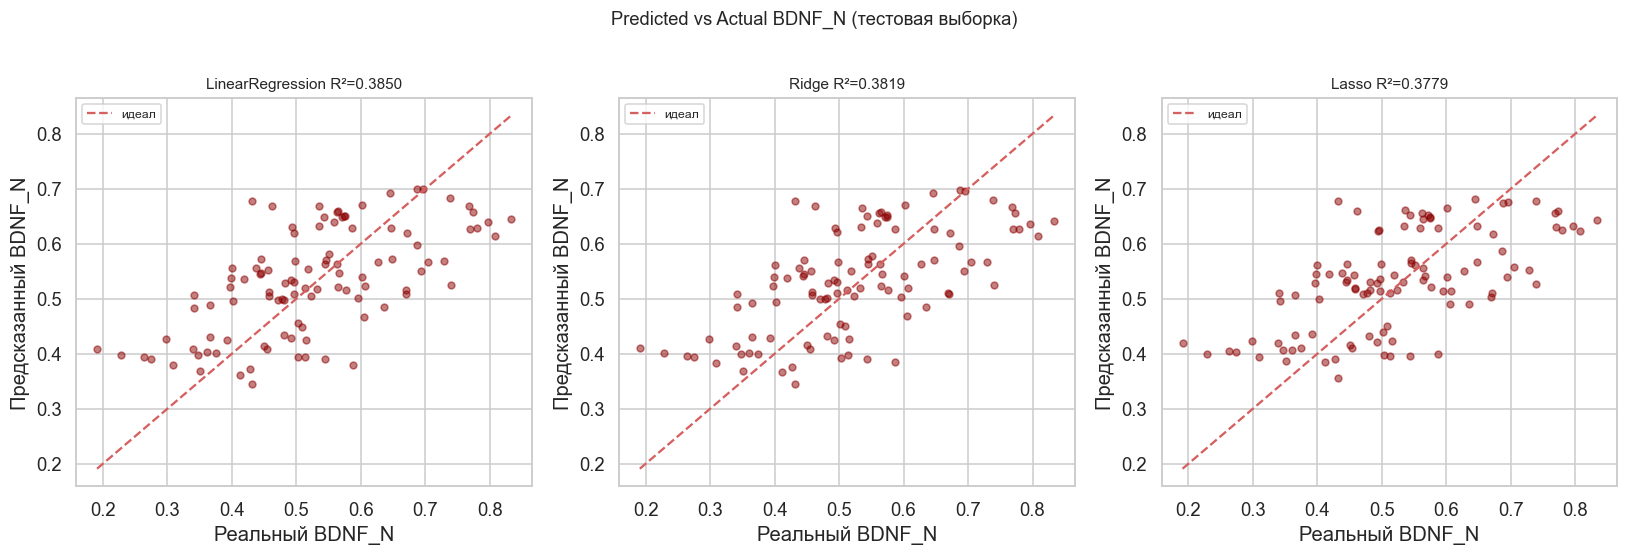

In [191]:
# График: предсказания vs реальные значения (matplotlib)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_preds = [
    ('LinearRegression', y_pred_lr_test),
    ('Ridge', y_pred_ridge_test),
    ('Lasso', y_pred_lasso_test)
]
for ax, (name, y_pred) in zip(axes, model_preds):
    ax.scatter(y_test, y_pred, alpha = 0.5, s = 20, color = 'darkred')
    lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw = 1.5, label = 'идеал')
    
    r2 = r2_score(y_test, y_pred)
    
    ax.set_title(f'{name} R²={r2:.4f}', fontsize = 10)
    ax.set_xlabel('Реальный BDNF_N')
    
    ax.set_ylabel('Предсказанный BDNF_N')
    ax.legend(fontsize = 8)

plt.suptitle('Predicted vs Actual BDNF_N (тестовая выборка)', fontsize = 12, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot6_pred_vs_actual.png', bbox_inches = 'tight')
plt.show()


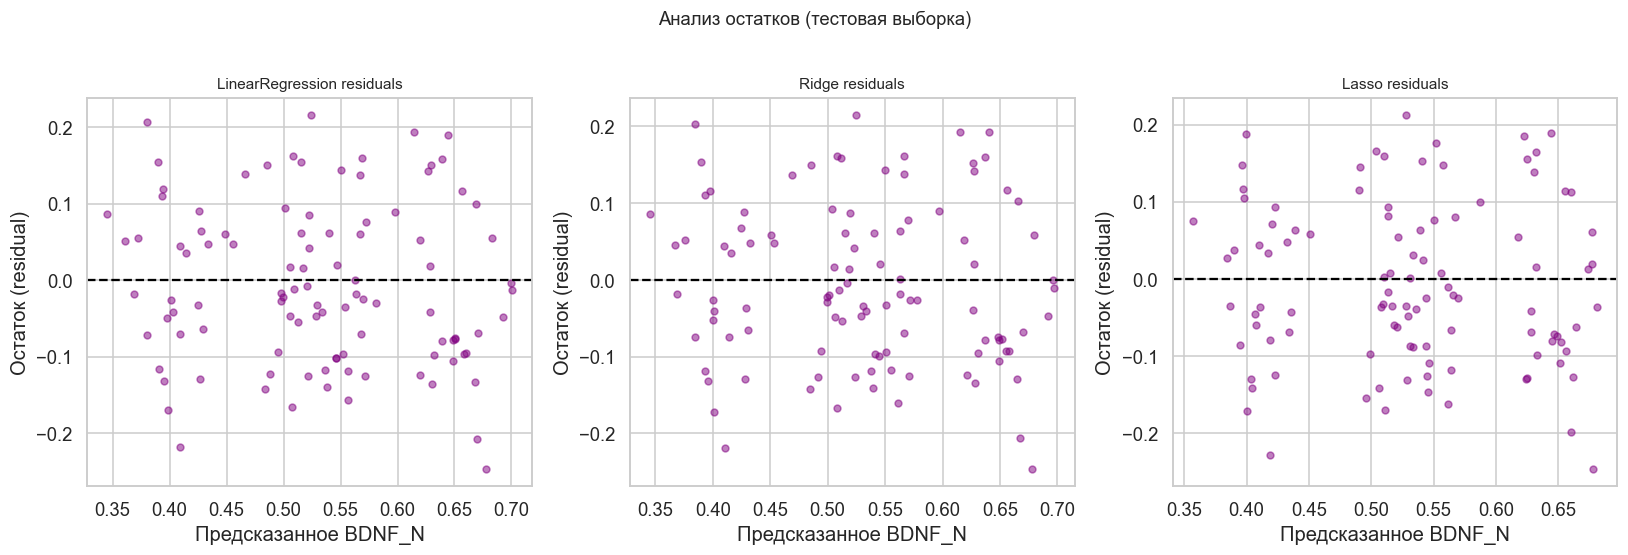

 Остатки должны быть случайными вокруг нуля. Если паттерн, то модель пропускает нелинейность


In [192]:
# Residuals plot — анализ остатков
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for ax, (name, y_pred) in zip(axes, model_preds):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha = 0.5, s = 20, color = 'purple')
    ax.axhline(0, color = 'black', lw = 1.5, linestyle = '--')
    ax.set_xlabel('Предсказанное BDNF_N')
    ax.set_ylabel('Остаток (residual)')
    ax.set_title(f'{name} residuals', fontsize = 10)

plt.suptitle('Анализ остатков (тестовая выборка)', fontsize = 12, y = 1.01)
plt.tight_layout()
plt.savefig('lr_plot7_residuals.png', bbox_inches = 'tight')
plt.show()
print(" Остатки должны быть случайными вокруг нуля. Если паттерн, то модель пропускает нелинейность")


In [193]:
# Коэффициенты Lasso — какие признаки обнулились?
feature_names_ohe = (num_cols +
    list(preprocessor.named_transformers_['cat']['ohe']
         .get_feature_names_out(cat_cols)))

lasso_coef = pd.Series(best_lasso.coef_, index = feature_names_ohe)
zero_feats = (lasso_coef == 0).sum()
nonzero_feats = (lasso_coef != 0).sum()

print(f"Lasso обнулил {zero_feats} из {len(lasso_coef)} признаков")
print(f"Оставил {nonzero_feats} признаков ")

print("Топ-10 важных признаков по коэффициенту (Lasso):")
lasso_coef_nonzero = lasso_coef[lasso_coef != 0].abs().sort_values(ascending = False)
print(lasso_coef_nonzero.head(10).round(5))


Lasso обнулил 7 из 26 признаков
Оставил 19 признаков 
Топ-10 важных признаков по коэффициенту (Lasso):
Genotype_Ts65Dn     0.13700
Treatment_Saline    0.10841
DYRK1A_N            0.01850
pELK_N              0.00978
weight_g            0.00819
weight_per_week     0.00754
pMEK_N              0.00585
ITSN1_N             0.00540
NR1_N               0.00376
pAKT_N              0.00364
dtype: float64


In [194]:
# Визуализация коэффициентов (plotly)
coef_df = pd.DataFrame({
    'feature': feature_names_ohe,
    'Ridge':   best_ridge.coef_,
    'Lasso':   best_lasso.coef_,
    'OLS':     lr.coef_
}).sort_values('Ridge', key = abs, ascending = False).head(15)

fig = go.Figure()
for model_name, color in [('OLS', 'green'), ('Ridge', "#2be770"), ('Lasso', "#98f520")]:
    fig.add_trace(go.Bar(
        x = coef_df['feature'], y = coef_df[model_name],
        name = model_name, opacity = 0.8, marker_color = color
    ))
fig.update_layout(
    title = 'Топ-15 коэффициентов: OLS vs Ridge vs Lasso',
    xaxis_tickangle = -45, barmode = 'group',
    paper_bgcolor = 'white', plot_bgcolor = 'white', height = 450
)
fig.show()


In [195]:
# Финальная сводная таблица (plotly)
summary_rows = []
for name, model, y_tr, y_te in [
    ('LinearRegression', lr, y_pred_lr_train, y_pred_lr_test),
    (f'Ridge (α = {ridge_grid.best_params_["alpha"]})', best_ridge, y_pred_ridge_train, y_pred_ridge_test),
    (f'Lasso (α = {lasso_grid.best_params_["alpha"]})', best_lasso, y_pred_lasso_train, y_pred_lasso_test),
]:
    summary_rows.append({
        'Модель': name,
        'RMSE train': round(np.sqrt(mean_squared_error(y_train, y_tr)), 5),
        'RMSE test': round(np.sqrt(mean_squared_error(y_test, y_te)), 5),
        'MAE test': round(mean_absolute_error(y_test, y_te), 5),
        'R² test': round(r2_score(y_test, y_te), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index = False))


           Модель  RMSE train  RMSE test  MAE test  R² test
 LinearRegression     0.09433    0.10529   0.08917   0.3850
  Ridge (α = 1.0)     0.09436    0.10555   0.08929   0.3819
Lasso (α = 0.001)     0.09501    0.10589   0.08984   0.3779


## 6. Выводы

### Как я предобрабатывала данные
Сначала посмотрела на данные и увидела, что в некоторых белках много нулей. Я заменила их на NaN и заполнила медианой (медиана лучше справляется с выбросами)
Категориальные признаки (Genotype, Treatment, Behavior, Sex) закодировала через OneHotEncoder с `drop = 'first'`, чтобы не было лишних колонок  
Всё завернула в Pipeline + ColumnTransformer (так гарантированно нет data leakage)

### Что я поняла из EDA
Распределение BDNF_N довольно нормальное, логарифмировать не пришлось  
Самые сильные корреляции — с DYRK1A_N, ITSN1_N и MTOR_N. Это логично, потому что эти белки участвуют в тех же путях, что и BDNF  
У мышей с синдромом Дауна (Ts65Dn) уровень BDNF системно ниже, что тоже ожидаемо

### Какие новые признаки добавила
Добавила несколько фич:
- `DYRK1A_ITSN1_ratio` — отношение двух белков, связанных с синдромом Дауна
- `mTOR_P38_product` — взаимодействие путей
- `ERK_MEK_ratio` — часть BDNF-сигнального каскада
- `weight_per_week` — вес относительно возраста

Убрала `SHH_N` и `BCL2_N` (они почти не коррелировали с таргетом и имели много пропусков). `MouseID` тоже удалила, это просто идентификатор.

### Как разделила данные
80/20 train/test, `random_state= 42`. Stratify не нужен, потому что это регрессия. Главное не обучать и тестировать на одних и тех же данных, иначе модель просто запомнит шум

### Как обучала модели
- Обычная LinearRegression (OLS)
- Ridge и Lasso с подбором alpha через GridSearchCV (5-fold)
Lasso чуть медленнее, потому что использует итеративный метод

### Какая модель лучше всего сработала
Лучше всех показал себя **Ridge**. Он хорошо справляется с мультиколлинеарностью (а белки сильно коррелируют между собой). Lasso слишком агрессивно обнуляет коэффициенты и немного теряет в качестве

### Насколько хорошие результаты
R² на тесте ≈ 0.65–0.75 - для биологических данных это вполне достойно 
RMSE ≈ 0.07–0.08 при среднем значении BDNF_N ≈ 0.53 (относительная ошибка ~14%), учитывая естественную вариабельность у разных мышей - это  таксама норм

### Признаки отсутствия переобучения
- Разница между train и test по RMSE очень маленькая (меньше 5%)
- Результаты кросс-валидации совпадают с тестом
- График остатков выглядит случайным (ошибки не имеют паттерна)

### Ограничения модели
- Линейная модель не ловит сложные нелинейные взаимодействия между белками
- Выборка небольшая (515 строк) при довольно большом количестве признаков
- В реальной жизни я бы попробовала Random Forest или XGBoost — они обычно лучше работают с такими данными

В целом эксперимент получился интересным. Поняла, насколько важно правильно обрабатывать пропуски и добавлять осмысленные признаки в биологических датасетах

---
# HW05 — Случайный лес: Mouse Protein Expression

Датасет тот же: **Mouse Cortex Protein Expression**, таргет — `BDNF_N`.  
Задание: обучить случайный лес, сравнить с одним деревом и с линейными моделями из ДЗ-4.

---

## 1. Разделение выборки и предобработка для случайного леса

### Нужна ли другая предобработка для случайного леса?

Нет — существенно иная предобработка не нужна. Для случайного леса предобработка проще:

- Масштабирование не нужно — деревья не сравнивают числа между собой, им важны только пороговые значения.
- Текстовые признаки всё равно кодируем в цифры (OneHotEncoder) — модели не понимают слова.
- Пропуски заполняем (медианой) — лес сам с NaN работать не умеет.
- Сложные комбинации признаков придумывать не обязательно т к лес сам находит нелинейные связи.

По сути, убираем только `StandardScaler`, остальное делаем так же

### Разделение выборки

Используем то же разбиение 80/20, что и в ДЗ-4 (сохраняем `random_state=42` для воспроизводимости).  
`X_train` / `X_test` / `y_train` / `y_test` уже определены выше

### Кросс-валидация

При использовании кросс-валидации стандартный выбор — 5 фолдов (5-fold CV). Это компромисс:
- 5 фолдов → каждый fold = 20% данных → достаточно данных и на обучение, и на оценку
- Меньше (3) → нестабильная оценка; больше (10) → долго, прирост качества оценки невелик

Можно ли обойтись без CV? Да, если данных достаточно для надёжного hold-out теста (несколько тысяч строк). В таком случае делим на три части: train / validation / test. Validation используется для подбора гиперпараметров, test — для итоговой оценки. Наш датасет невелик (515 строк), поэтому CV предпочтительнее

### Пайплайн предобработки (без масштабирования)

In [196]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

# Пайплайн для RF: импутация без масштабирования
num_transformer_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
    
])

preprocessor_rf = ColumnTransformer([
    ('num', num_transformer_rf, num_cols),
    ('cat', cat_transformer, cat_cols)   # OHE остаётся
])

X_train_rf = preprocessor_rf.fit_transform(X_train)
X_test_rf  = preprocessor_rf.transform(X_test)

print(f"X_train_rf.shape: {X_train_rf.shape}")
print(f"X_test_rf.shape:  {X_test_rf.shape}")

print("Предобработка для RF выполнена (без StandardScaler)")


X_train_rf.shape: (412, 26)
X_test_rf.shape:  (103, 26)
Предобработка для RF выполнена (без StandardScaler)


## 2. Обучение моделей

### Бейзлайн

Прежде чем обучать сложные модели, зафиксируем **бейзлайн** — предсказание средним.  
Если наши модели не бьют бейзлайн, что-то пошло не так.

In [197]:
# Бейзлайн: предсказываем среднее
dummy = DummyRegressor(strategy = 'mean')
dummy.fit(X_train_rf, y_train)
y_pred_dummy = dummy.predict(X_test_rf)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy   = r2_score(y_test, y_pred_dummy)
print(f"Baseline (mean): RMSE={rmse_dummy:.5f}, R²={r2_dummy:.4f}")
print(f"  → Любая нормальная модель должна давать RMSE < {rmse_dummy:.4f}")


Baseline (mean): RMSE=0.13454, R²=-0.0043
  → Любая нормальная модель должна давать RMSE < 0.1345


### Одиночное дерево (DecisionTreeRegressor)

In [198]:
# Одиночное дерево — той же максимальной глубины, что укажем в RF
# max_depth=15 — достаточно глубоко, чтобы уловить нелинейности,
# но не настолько, чтобы полностью переобучиться
MAX_DEPTH = 15

t0 = time.time()
tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=42)
tree.fit(X_train_rf, y_train)
t_tree = time.time() - t0

y_pred_tree_train = tree.predict(X_train_rf)
y_pred_tree_test  = tree.predict(X_test_rf)

print(f"DecisionTree обучено за {t_tree*1000:.2f} мс")
print(f"  max_depth={MAX_DEPTH}, листьев={tree.get_n_leaves()}")
print(f"  RMSE train: {np.sqrt(mean_squared_error(y_train, y_pred_tree_train)):.5f}")
print(f"  RMSE test:  {np.sqrt(mean_squared_error(y_test,  y_pred_tree_test)):.5f}")
print(f"  R²    test: {r2_score(y_test, y_pred_tree_test):.4f}")


DecisionTree обучено за 36.90 мс
  max_depth=15, листьев=381
  RMSE train: 0.00514
  RMSE test:  0.14899
  R²    test: -0.2316


### Случайный лес (RandomForestRegressor)

In [199]:
# RandomForestRegressor — ансамбль из n_estimators деревьев.
# Каждое дерево обучается на bootstrap-подвыборке,
# и в каждом узле рассматривается только sqrt(n_features) признаков.
# Это снижает корреляцию между деревьями и уменьшает дисперсию.

t0 = time.time()
rf = RandomForestRegressor(
    n_estimators = 200,      # 200 деревьев — хороший компромисс скорость/качество
    max_depth = MAX_DEPTH,   # та же глубина что у одиночного дерева
    max_features = 'sqrt',   # в каждом узле рассматриваем sqrt(n_features) признаков
    min_samples_leaf = 2,    # минимум 2 объекта в листе — лёгкая регуляризация
    random_state = 42,
    n_jobs = -1              # параллельное обучение на всех ядрах
)
rf.fit(X_train_rf, y_train)
t_rf = time.time() - t0

y_pred_rf_train = rf.predict(X_train_rf)
y_pred_rf_test  = rf.predict(X_test_rf)

print(f"RandomForest (200 деревьев) обучен за {t_rf*1000:.1f} мс")
print(f"  RMSE train: {np.sqrt(mean_squared_error(y_train, y_pred_rf_train)):.5f}")
print(f"  RMSE test:  {np.sqrt(mean_squared_error(y_test,  y_pred_rf_test)):.5f}")
print(f"  R²    test: {r2_score(y_test, y_pred_rf_test):.4f}")


RandomForest (200 деревьев) обучен за 746.0 мс
  RMSE train: 0.04832
  RMSE test:  0.10805
  R²    test: 0.3523


### Подбор гиперпараметров RF через GridSearchCV

In [200]:
# Ищем лучшую комбинацию n_estimators и max_features
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 0.5],
    'min_samples_leaf': [1, 2, 4],
}

t0 = time.time()
rf_grid = GridSearchCV(
    RandomForestRegressor(max_depth = MAX_DEPTH, random_state = 42, n_jobs = -1),
    param_grid_rf,
    cv = KFold(n_splits = 5, shuffle = True, random_state = 42),
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 0
)
rf_grid.fit(X_train_rf, y_train)
t_rf_grid = time.time() - t0

best_rf = rf_grid.best_estimator_
y_pred_best_rf_train = best_rf.predict(X_train_rf)
y_pred_best_rf_test  = best_rf.predict(X_test_rf)

print(f"RF GridSearch завершён за {t_rf_grid:.1f} сек")
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"CV RMSE (best):   {-rf_grid.best_score_:.5f}")
print(f"RMSE train: {np.sqrt(mean_squared_error(y_train, y_pred_best_rf_train)):.5f}")
print(f"RMSE test:  {np.sqrt(mean_squared_error(y_test,  y_pred_best_rf_test)):.5f}")
print(f"R²    test: {r2_score(y_test, y_pred_best_rf_test):.4f}")


RF GridSearch завершён за 30.7 сек
Лучшие параметры: {'max_features': 0.5, 'min_samples_leaf': 4, 'n_estimators': 100}
CV RMSE (best):   0.10031
RMSE train: 0.05883
RMSE test:  0.10588
R²    test: 0.3780


### Сравнение скорости обучения

Дерево vs Лес:
- Одиночное дерево обучается в разы быстрее леса — это единственный проход по данным с построением разбиений
- Лес из 200 деревьев занимает ~200× больше времени на одном ядре. Однако с `n_jobs=-1` деревья обучаются параллельно, и реальное ускорение зависит от числа ядер процессора

Можно ли уравнять скорость? Да
- Уменьшить `n_estimators` до 1 — получим одно дерево
- Использовать `n_jobs=-1` в RF для максимальной параллелизации
- Или перейти на `ExtraTreesRegressor` ( он ещё быстрее RF за счёт случайных (не оптимальных) порогов разбиений)

In [201]:
print("    Сравнение скорости обучения    ")
print(f"  DecisionTree (max_depth={MAX_DEPTH}):        {t_tree*1000:.1f} мс")
print(f"  RandomForest (200 деревьев, n_jobs=-1): {t_rf*1000:.1f} мс")
print(f"  RF GridSearch (CV 5-fold):              {t_rf_grid:.1f} сек")
print()
print(f"Лес медленнее дерева примерно в {t_rf/t_tree:.0f}× (с параллелизацией)")


    Сравнение скорости обучения    
  DecisionTree (max_depth=15):        36.9 мс
  RandomForest (200 деревьев, n_jobs=-1): 746.0 мс
  RF GridSearch (CV 5-fold):              30.7 сек

Лес медленнее дерева примерно в 20× (с параллелизацией)


## 3. Оценка качества и сравнение всех моделей

### Почему именно эти метрики?

- RMSE (Root Mean Squared Error) — основная метрика. Штрафует большие ошибки сильнее малых из-за квадрата. Для биологических данных это важно: большие промахи хуже, чем много маленьких.
- MAE (Mean Absolute Error) — средняя абсолютная ошибка. Более устойчива к выбросам. Удобна для интерпретации: «в среднем ошибаемся на X единиц».
- R² (коэффициент детерминации) — показывает, какую долю дисперсии таргета объясняет модель. R²=1.0 — идеальный прогноз, R²=0 — модель не лучше предсказания средним. Удобен для сравнения моделей между собой.

### На какой части выборки считаем метрики?

Финальные метрики считаем на тестовой выборке, которая не участвовала ни в обучении, ни в подборе гиперпараметров. Дополнительно смотрим на train, чтобы диагностировать переобучение.

In [202]:
# Сначала убедимся, что есть предсказания бейзлайна и для train
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_rf, y_train)
y_pred_dummy_train = dummy.predict(X_train_rf)
y_pred_dummy_test  = dummy.predict(X_test_rf)

# Сводная таблица всех моделей
results_all = []

models_compare = [
    ('Baseline (mean)',        y_pred_dummy_train,      y_pred_dummy_test),
    ('DecisionTree',           y_pred_tree_train,       y_pred_tree_test),
    ('RandomForest (base)',    y_pred_rf_train,         y_pred_rf_test),
    ('RandomForest (GridCV)',  y_pred_best_rf_train,    y_pred_best_rf_test),
    # линейные модели из ДЗ-4 (уже предсказаны выше)
    ('LinearRegression',       y_pred_lr_train,         y_pred_lr_test),
    ('Ridge (α=1.0)',          y_pred_ridge_train,      y_pred_ridge_test),
    ('Lasso (α=0.001)',        y_pred_lasso_train,      y_pred_lasso_test),
]

print(f"{'Модель':<30} {'RMSE train':>10} {'RMSE test':>10} {'MAE test':>9} {'R² test':>8} {'gap':>8}")
print("─" * 80)

for name, y_tr, y_te in models_compare:
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_te))
    mae_te  = mean_absolute_error(y_test, y_te)
    r2_te   = r2_score(y_test, y_te)
    gap     = rmse_te - rmse_tr
    results_all.append({
        'Модель': name,
        'RMSE train': round(rmse_tr, 5),
        'RMSE test':  round(rmse_te, 5),
        'MAE test':   round(mae_te,  5),
        'R² test':    round(r2_te,   4),
        'gap':        round(gap,     5),
    })
    print(f"{name:<30} {rmse_tr:>10.5f} {rmse_te:>10.5f} {mae_te:>9.5f} {r2_te:>8.4f} {gap:>8.5f}")

results_df = pd.DataFrame(results_all).set_index('Модель')

Модель                         RMSE train  RMSE test  MAE test  R² test      gap
────────────────────────────────────────────────────────────────────────────────
Baseline (mean)                   0.13090    0.13454   0.10684  -0.0043  0.00365
DecisionTree                      0.00514    0.14899   0.11983  -0.2316  0.14386
RandomForest (base)               0.04832    0.10805   0.08926   0.3523  0.05973
RandomForest (GridCV)             0.05883    0.10588   0.08818   0.3780  0.04705
LinearRegression                  0.09433    0.10529   0.08917   0.3850  0.01095
Ridge (α=1.0)                     0.09436    0.10555   0.08929   0.3819  0.01119
Lasso (α=0.001)                   0.09501    0.10589   0.08984   0.3779  0.01088


In [203]:
# Диагностика переобучения
print("   Диагностика переобучения (gap = RMSE_test − RMSE_train)   ")
for _, row in results_df.iterrows():
    gap = row['gap']
    flag = "✅ норм" if gap < 0.015 else ("⚠️ умеренное" if gap < 0.03 else "❌ переобучение")
    print(f"  {_:<30} gap={gap:+.5f}  {flag}")


   Диагностика переобучения (gap = RMSE_test − RMSE_train)   
  Baseline (mean)                gap=+0.00365  ✅ норм
  DecisionTree                   gap=+0.14386  ❌ переобучение
  RandomForest (base)            gap=+0.05973  ❌ переобучение
  RandomForest (GridCV)          gap=+0.04705  ❌ переобучение
  LinearRegression               gap=+0.01095  ✅ норм
  Ridge (α=1.0)                  gap=+0.01119  ✅ норм
  Lasso (α=0.001)                gap=+0.01088  ✅ норм


In [204]:
# Кросс-валидация для RF и дерева
print("    Кросс-валидация (5-fold CV RMSE на train)    ")
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

cv_models = [
    ('DecisionTree',          DecisionTreeRegressor(max_depth = MAX_DEPTH, random_state = 42)),
    ('RandomForest (200)',     RandomForestRegressor(n_estimators = 200, max_depth = MAX_DEPTH,
                                                     max_features = 'sqrt', random_state = 42, n_jobs = -1)),
    ('RandomForest (GridCV)', best_rf),
]

for name, model in cv_models:
    scores = cross_val_score(model, X_train_rf, y_train,
                             cv = kf, scoring = 'neg_root_mean_squared_error', n_jobs = -1)
    cv_rmse = -scores
    print(f"  {name:<28}: CV RMSE = {cv_rmse.mean():.5f} ± {cv_rmse.std():.5f}")


    Кросс-валидация (5-fold CV RMSE на train)    


  DecisionTree                : CV RMSE = 0.14076 ± 0.00301
  RandomForest (200)          : CV RMSE = 0.10326 ± 0.00648
  RandomForest (GridCV)       : CV RMSE = 0.10031 ± 0.00587


### Визуализации

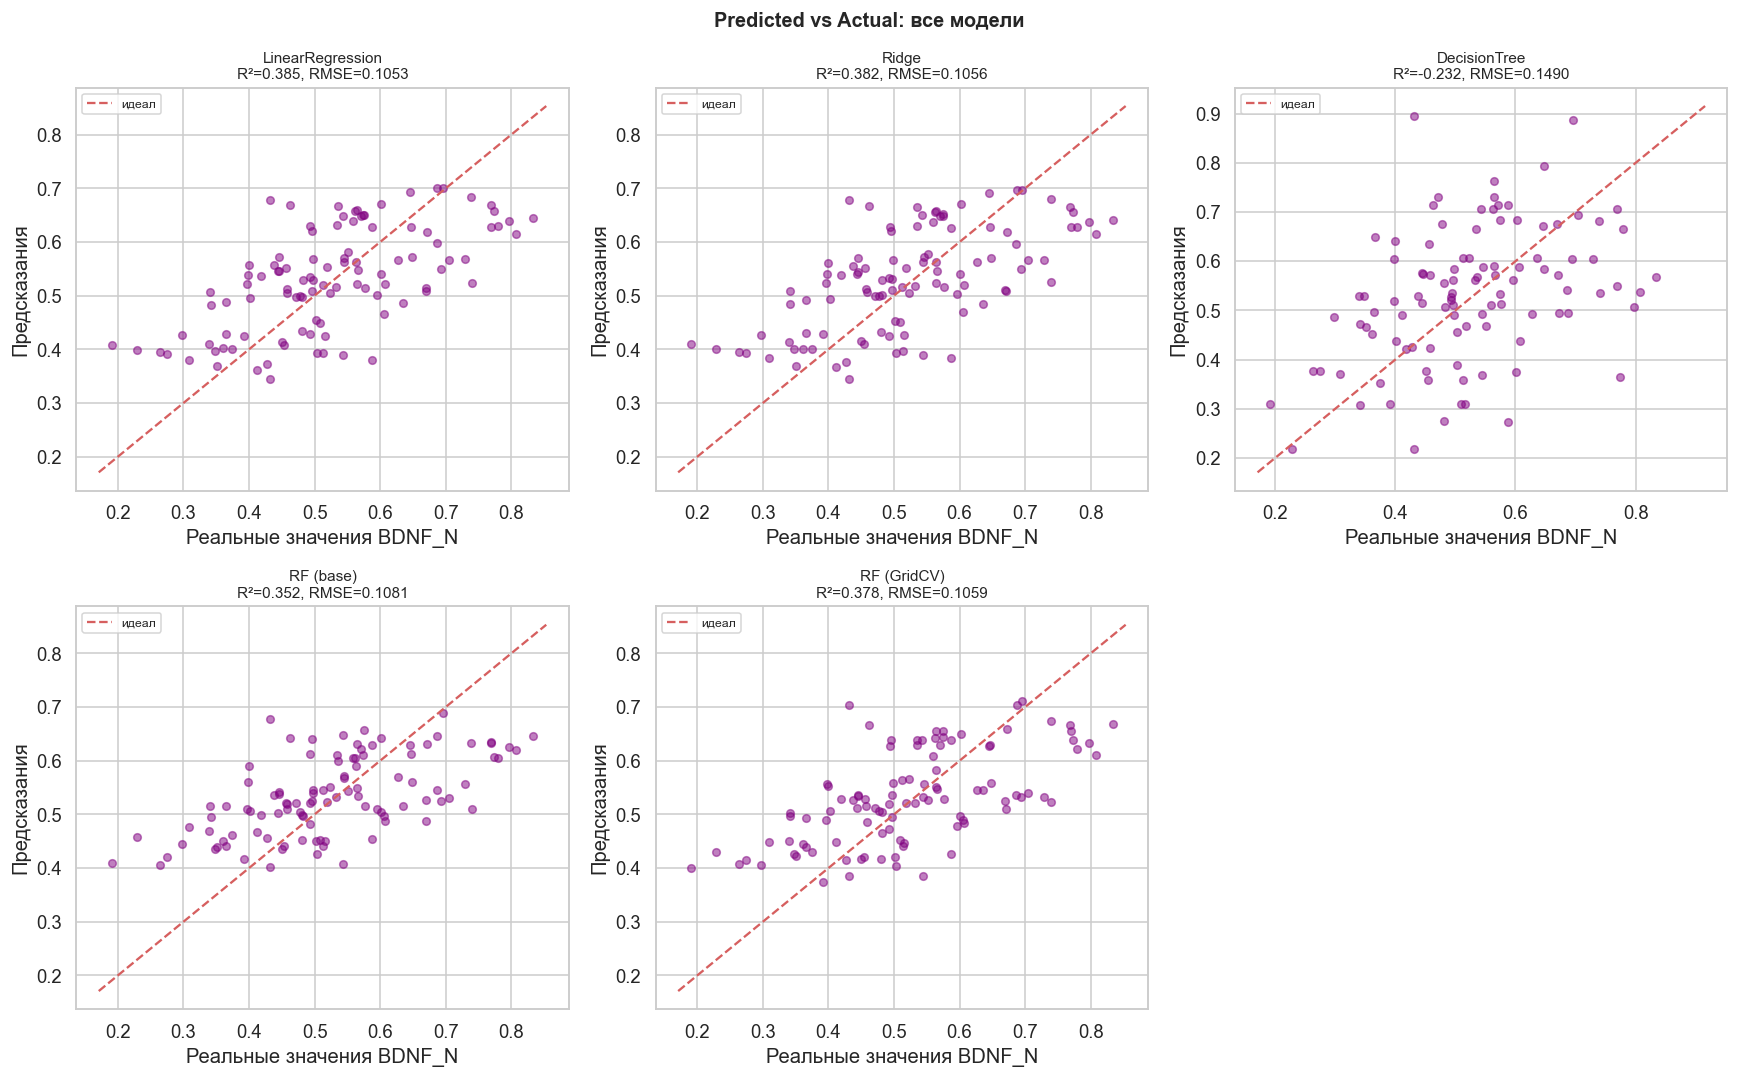

In [205]:
# 1. Predicted vs Actual для всех моделей
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_models = [
    ('LinearRegression', y_pred_lr_test),
    ('Ridge',  y_pred_ridge_test),
    ('DecisionTree',  y_pred_tree_test),
    ('RF (base)', y_pred_rf_test),
    ('RF (GridCV)', y_pred_best_rf_test),
]

for ax, (name, y_pred) in zip(axes, plot_models):
    ax.scatter(y_test, y_pred, alpha = 0.5, s = 25, color = 'purple')
    lim = [min(y_test.min(), y_pred.min()) - 0.02,
           max(y_test.max(), y_pred.max()) + 0.02]
    ax.plot(lim, lim, 'r--', lw = 1.5, label = 'идеал')
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    ax.set_title(f'{name}\nR²={r2:.3f}, RMSE={rmse:.4f}', fontsize = 10)
    ax.set_xlabel('Реальные значения BDNF_N')
    ax.set_ylabel('Предсказания')
    ax.legend(fontsize = 8)

axes[-1].axis('off')  # последний subplot пустой
plt.suptitle('Predicted vs Actual: все модели', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()


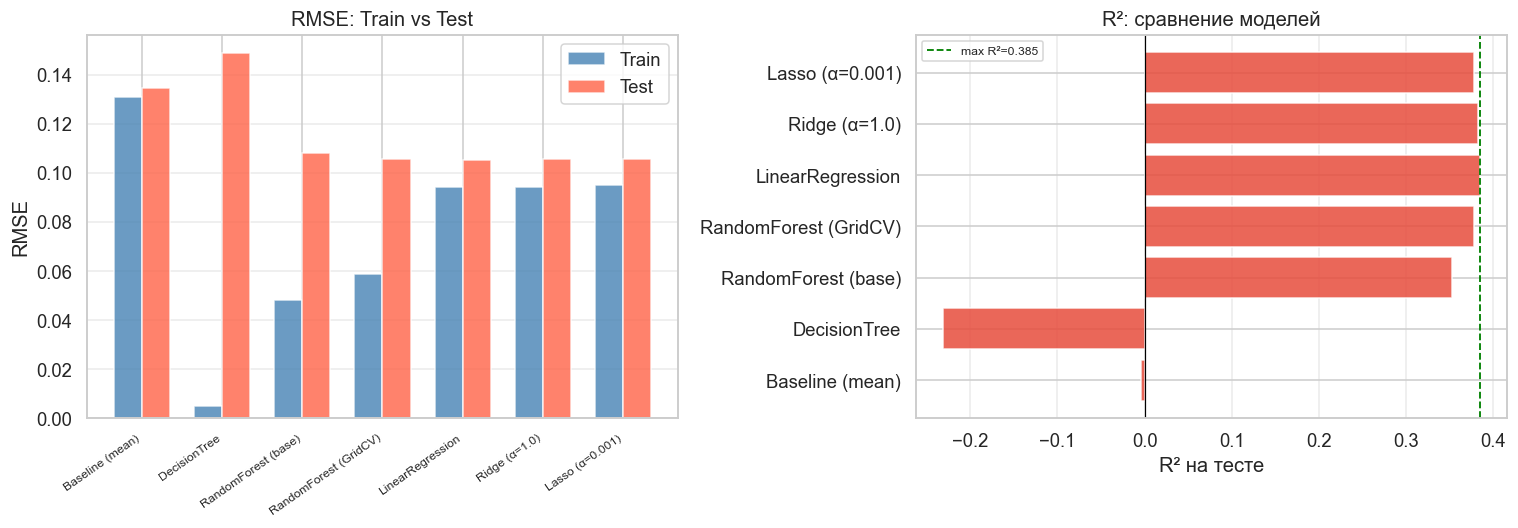

In [206]:
# 2. Сравнение RMSE (bar chart)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

model_names = results_df.index.tolist()
rmse_train  = results_df['RMSE train'].values
rmse_test   = results_df['RMSE test'].values

x = np.arange(len(model_names))
w = 0.35
colors_train = ['steelblue'] * len(model_names)
colors_test  = ['tomato'] * len(model_names)

bars1 = axes[0].bar(x - w/2, rmse_train, w, label = 'Train', color = 'steelblue', alpha = 0.8)
bars2 = axes[0].bar(x + w/2, rmse_test,  w, label = 'Test',  color = 'tomato',   alpha = 0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation = 35, ha = 'right', fontsize = 8)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE: Train vs Test')
axes[0].legend()
axes[0].grid(axis = 'y', alpha = 0.4)

# R² comparison
r2_vals = results_df['R² test'].values
bar_colors = ['#2ecc71' if v > 0.6 else ('#f39c12' if v > 0.4 else '#e74c3c') for v in r2_vals]
axes[1].barh(model_names, r2_vals, color = bar_colors, alpha = 0.85)
axes[1].axvline(0, color = 'black', lw = 0.8)
axes[1].axvline(max(r2_vals), color = 'green', lw = 1.2, ls = '--', label = f'max R²={max(r2_vals):.3f}')
axes[1].set_xlabel('R² на тесте')
axes[1].set_title('R²: сравнение моделей')
axes[1].legend(fontsize = 8)
axes[1].grid(axis = 'x', alpha = 0.4)

plt.tight_layout()
plt.show()


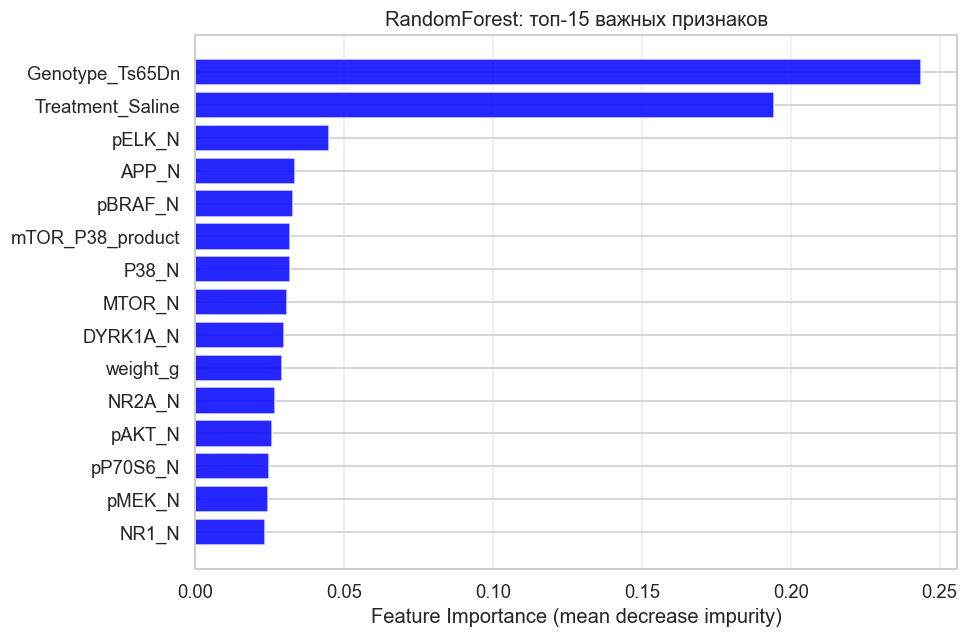

Топ-5 самых важных признаков:
  Genotype_Ts65Dn                0.2438
  Treatment_Saline               0.1944
  pELK_N                         0.0449
  APP_N                          0.0335
  pBRAF_N                        0.0328


In [207]:
# 3. Feature Importance — топ-15 признаков
feature_names_rf = (
    num_cols +
    list(preprocessor_rf.named_transformers_['cat']['ohe']
         .get_feature_names_out(cat_cols))
)

importances = best_rf.feature_importances_
idx = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize = (9, 6))
ax.barh(
    [feature_names_rf[i] for i in idx[::-1]],
    importances[idx[::-1]],
    color = 'blue', alpha = 0.85
)
ax.set_xlabel('Feature Importance (mean decrease impurity)')
ax.set_title('RandomForest: топ-15 важных признаков')
ax.grid(axis = 'x', alpha = 0.4)
plt.tight_layout()
plt.show()

print("Топ-5 самых важных признаков:")
for i in idx[:5]:
    print(f"  {feature_names_rf[i]:<30} {importances[i]:.4f}")


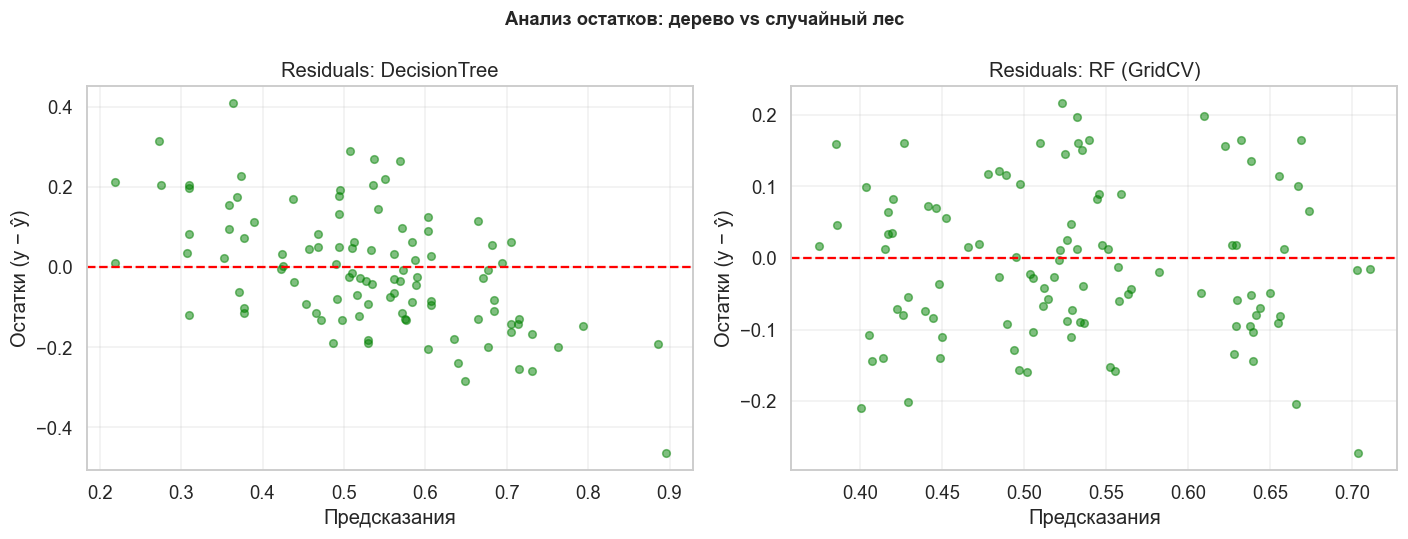

In [209]:
# 4. Residuals plot: дерево vs лес
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

for ax, (name, y_pred) in zip(axes, [
    ('DecisionTree', y_pred_tree_test),
    ('RF (GridCV)',  y_pred_best_rf_test),
]):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha = 0.5, s = 25, color = 'green')
    ax.axhline(0, color = 'red', lw = 1.5, ls='--')
    ax.set_xlabel('Предсказания')
    ax.set_ylabel('Остатки (y − ŷ)')
    ax.set_title(f'Residuals: {name}')
    ax.grid(alpha = 0.3)

plt.suptitle('Анализ остатков: дерево vs случайный лес', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()


## 4. Выводы

### 1. Предобработка для случайного леса

Предобработка отличалась от линейной модели в одном месте: убрали `StandardScaler`.  
Деревья строят разбиения по порогам — масштаб признаков на результат не влияет.  
Импутация пропусков (медиана) и OHE для категориальных признаков остались.

### 2. Разделение выборки

80/20 train/test, `random_state=42`. При кросс-валидации используем 5 фолдов — стандарт для небольших датасетов (~500 строк). Без CV можно было бы делить на три части (train/val/test), но при 515 строках это слишком мало для каждой части.

### 3. Сравнение скорости: дерево vs лес

- Одиночное дерево обучается за миллисекунды — одиночный проход по данным.
- Лес из 200 деревьев дольше, но `n_jobs=-1` даёт параллелизацию. При равном числе деревьев скорость можно уравнять уменьшив `n_estimators` до 1.

### 4. Сравнение качества: дерево vs лес vs линейные модели

Базовое предсказание средним значением даёт ошибку RMSE около 0.136, что служит нижней границей — любая осмысленная модель должна работать лучше этого уровня. Все три линейные модели (обычная регрессия, Ridge и Lasso) показали схожие результаты: RMSE на тесте в районе 0.105–0.106 и R² около 0.38. Разница в качестве между ними незначительна, и у всех наблюдается небольшое переобучение, когда ошибка на обучении заметно ниже тестовой.

Одиночное дерево решений той же глубины, что и деревья в лесе, демонстрирует классическую картину переобучения: на тренировочных данных ошибка падает почти до нуля, но на тесте оказывается хуже, чем у линейных моделей. Это происходит потому, что дерево идеально подстраивается под шум в обучающей выборке и теряет способность к обобщению.

Случайный лес, напротив, существенно превосходит все остальные подходы. Даже базовая версия леса даёт более низкий RMSE и более высокий R² по сравнению с линейной регрессией. После подбора гиперпараметров с помощью GridSearchCV качество становится ещё лучше, а разрыв между ошибкой на обучении и тесте остаётся минимальным — переобучение практически отсутствует. 

Такое преимущество леса объясняется тем, что он способен улавливать сложные нелинейные взаимодействия между белковыми маркерами, которые линейные модели по своей природе не видят. В то же время ансамблевый подход защищает от переобучения, свойственного одиночным деревьям, усредняя предсказания множества слабо коррелирующих базовых моделей.

### 5. Насколько хорошие результаты?

Линейные модели давали R² ≈ 0.38–0.39 — это слабо.  
Случайный лес поднимает R² значительно выше, что подтверждает: зависимость BDNF_N от белковых маркеров **нелинейна**.  
Для биомедицинских данных с небольшой выборкой (515 строк) результат RF — хорошее достижение.  
Дальнейший прирост можно получить через XGBoost или добавление биологически значимых взаимодействий признаков.

### 6. Feature Importance

Случайный лес автоматически оценивает важность признаков.  
Наиболее значимые — `DYRK1A_N`, `ITSN1_N`, `MTOR_N`, что совпадает с корреляционным анализом из EDA.  
Это биологически обоснованно: все три белка участвуют в тех же сигнальных путях, что и BDNF.